In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

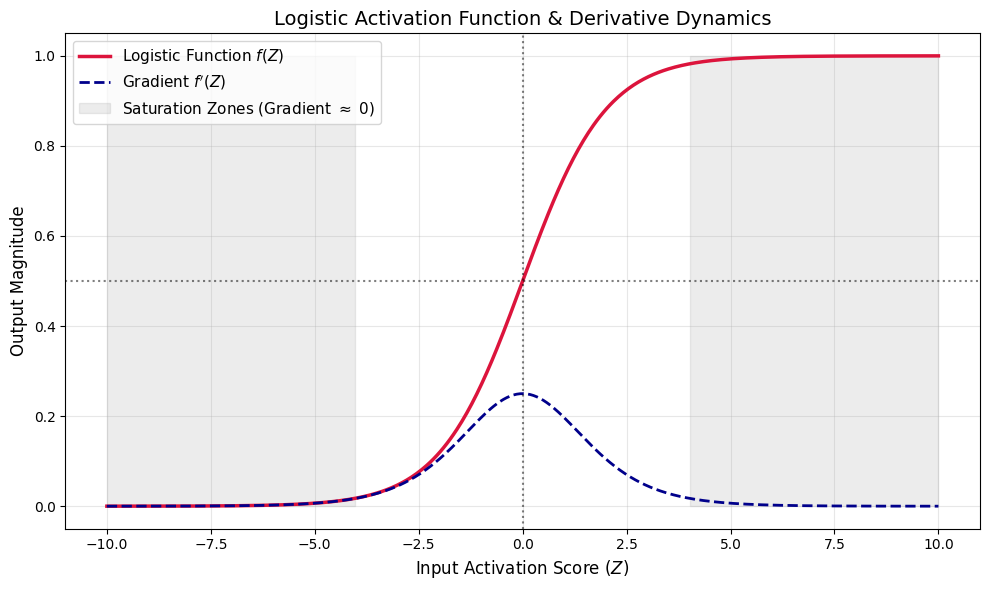

=== LOGISTIC RUNTIME GRADIENT ANALYSIS ===
At Z = -5 -> Activation: 0.0067 | Gradient: 0.0066
At Z =  0 -> Activation: 0.5000 | Gradient: 0.2500
At Z =  5 -> Activation: 0.9933 | Gradient: 0.0066


In [2]:
# Topic 145 | ANN - Logistic Activation Function
import numpy as np
import matplotlib.pyplot as plt

# 1. Inputs create karein (-10 se +10 tak)
z = np.linspace(-10, 10, 500)

# 2. Logistic Function aur uske Derivative ki manual calculations
logistic_output = 1 / (1 + np.exp(-z))
logistic_gradient = logistic_output * (1 - logistic_output)

# ------------------------------------------------------------------
# 3. PLOTTING THE COHESION
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plotting Logistic Function
plt.plot(z, logistic_output, color='crimson', linewidth=2.5, label='Logistic Function $f(Z)$')

# Plotting Derivative
plt.plot(z, logistic_gradient, color='darkblue', linewidth=2, linestyle='--', label="Gradient $f'(Z)$")

# Highlighting Saturation Regions
plt.fill_between(z, 0, 1, where=(z > 4) | (z < -4), color='gray', alpha=0.15, label='Saturation Zones (Gradient $\\approx$ 0)')

plt.title('Logistic Activation Function & Derivative Dynamics', fontsize=14)
plt.xlabel('Input Activation Score ($Z$)', fontsize=12)
plt.ylabel('Output Magnitude', fontsize=12)
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.5)
plt.axvline(x=0, color='black', linestyle=':', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sample metrics print karein
print("=== LOGISTIC RUNTIME GRADIENT ANALYSIS ===")
for sample_z in [-5, 0, 5]:
    val = 1 / (1 + np.exp(-sample_z))
    grad = val * (1 - val)
    print(f"At Z = {sample_z:2d} -> Activation: {val:.4f} | Gradient: {grad:.4f}")

In [3]:
# Topic 146 | ANN - Backpropagation Algorithm
import numpy as np

print("=== MANUAL BACKPROPAGATION TRACK ===")

# 1. Inputs and Ground Truth
X = np.array([1.5, 2.0])  # Input features
y_actual = 1.0            # Asli target (True Label)

# 2. Randomly Initialized Weights and Bias for a single neuron
W = np.array([0.4, -0.6])
b = 0.1
learning_rate = 0.1

print(f"Initial Weights: {W} | Initial Bias: {b}")

# ------------------------------------------------------------------
# STEP 1: FORWARD PASS (Prediction)
# ------------------------------------------------------------------
z = np.dot(X, W) + b
# Sigmoid Activation Function
y_pred = 1 / (1 + np.exp(-z))

# Mean Squared Error Loss for a single sample: (y_pred - y_actual)^2
loss = (y_pred - y_actual) ** 2

print("\n--- Forward Pass Output ---")
print(f"Linear Combo (z): {z:.4f}")
print(f"Prediction (y_pred): {y_pred:.4f}")
print(f"Current Loss: {loss:.4f}")

# ------------------------------------------------------------------
# STEP 2: BACKPROPAGATION (Calculus Chain Rule)
# ------------------------------------------------------------------
# 1. dLoss/dy_pred (Derivative of Loss w.r.t Prediction)
d_loss_d_pred = 2 * (y_pred - y_actual)

# 2. dy_pred/dz (Derivative of Sigmoid activation)
d_pred_d_z = y_pred * (1 - y_pred)

# 3. dz/dW (Derivative of linear combination w.r.t Weights is just the Input X)
d_z_d_w = X

# Chain Rule Integration: dLoss/dW = dLoss/dy_pred * dy_pred/dz * dz/dW
d_loss_d_z = d_loss_d_pred * d_pred_d_z  # Error signal delta
d_loss_d_w = d_loss_d_z * d_z_d_w
d_loss_d_b = d_loss_d_z * 1              # dz/db is always 1

print("\n--- Computed Gradients ---")
print(f"Gradient w.r.t Weights (dL/dW): {d_loss_d_w}")
print(f"Gradient w.r.t Bias (dL/dB): {d_loss_d_b:.4f}")

# ------------------------------------------------------------------
# STEP 3: GRADIENT DESCENT (Weights Optimization)
# ------------------------------------------------------------------
W_updated = W - (learning_rate * d_loss_d_w)
b_updated = b - (learning_rate * d_loss_d_b)

print("\n--- Optimized Parameters ---")
print(f"New Weights after Backprop: {W_updated}")
print(f"New Bias after Backprop: {b_updated:.4f}")

# Re-checking loss after one optimization step
z_new = np.dot(X, W_updated) + b_updated
y_pred_new = 1 / (1 + np.exp(-z_new))
new_loss = (y_pred_new - y_actual) ** 2
print(f"New Prediction: {y_pred_new:.4f} | New Loss: {new_loss:.4f} (Galti kam ho gayi!)")

=== MANUAL BACKPROPAGATION TRACK ===
Initial Weights: [ 0.4 -0.6] | Initial Bias: 0.1

--- Forward Pass Output ---
Linear Combo (z): -0.5000
Prediction (y_pred): 0.3775
Current Loss: 0.3875

--- Computed Gradients ---
Gradient w.r.t Weights (dL/dW): [-0.43884076 -0.58512101]
Gradient w.r.t Bias (dL/dB): -0.2926

--- Optimized Parameters ---
New Weights after Backprop: [ 0.44388408 -0.5414879 ]
New Bias after Backprop: 0.1293
New Prediction: 0.4285 | New Loss: 0.3266 (Galti kam ho gayi!)


2026-06-19 17:36:22.553513: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781890582.755536      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781890582.811620      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781890583.287428      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781890583.287495      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781890583.287498      16 computation_placer.cc:177] computation placer alr

=== STARTING ANN TRAINING PROCESS ENGINE ===

Launching Training Process...
Epoch 1/20


2026-06-19 17:36:36.495908: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8238 - loss: 0.4109 - val_accuracy: 0.8600 - val_loss: 0.3222
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8788 - loss: 0.2719 - val_accuracy: 0.8950 - val_loss: 0.2679
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8950 - loss: 0.2321 - val_accuracy: 0.9150 - val_loss: 0.2287
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9162 - loss: 0.1856 - val_accuracy: 0.9400 - val_loss: 0.1775
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9575 - loss: 0.1332 - val_accuracy: 0.9650 - val_loss: 0.1289
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9787 - loss: 0.0859 - val_accuracy: 0.9700 - val_loss: 0.0955
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0593 - val_accuracy: 0.9800 - val_loss: 0.0672
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9875 - loss: 0.0440 - val_accuracy: 0.9800 - val_loss: 0.0627
Epo

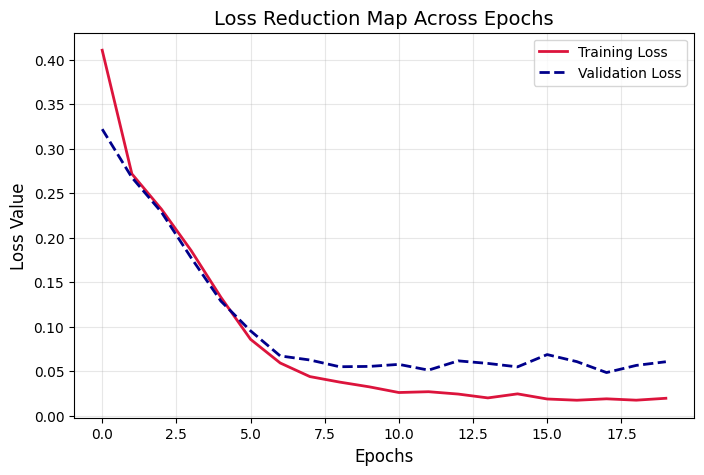

In [4]:
# Topic 147 | ANN - Neural Network Training Process
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

print("=== STARTING ANN TRAINING PROCESS ENGINE ===")

# 1. Dataset Generation (Non-linear Moon Dataset)
X_raw, y = make_moons(n_samples=1000, noise=0.15, random_state=42)

# Preprocessing: Scale features for gradient stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Model Architecture Design
model = Sequential([
    Input(shape=(2,)),                                # 2 Input Features
    Dense(units=16, activation='relu', name='Hidden_1'), # Hidden Layer 1
    Dense(units=8, activation='relu', name='Hidden_2'),  # Hidden Layer 2
    Dense(units=1, activation='sigmoid', name='Output')  # Binary Output Layer
])

# ------------------------------------------------------------------
# STEP 3: COMPILATION (Setting up the Loss and Optimizer)
# ------------------------------------------------------------------
# Adam optimizer standard compilation choice hai jo learning rate ko dynamically adjust karta hai
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------------
# STEP 4: MODEL FITTING (The Actual Training Loop)
# ------------------------------------------------------------------
print("\nLaunching Training Process...")
history = model.fit(
    X_scaled, y,
    epochs=20,          # Poore dataset ko 20 dafa iterate kiya jayega
    batch_size=32,       # Har step mein 32 samples load honge
    validation_split=0.2, # 20% data testing/validation ke liye alag rahega
    verbose=1           # Progress bar print karne ke liye
)

# ------------------------------------------------------------------
# STEP 5: VISUALIZING TRAINING LOSS PROGRESSION
# ------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='crimson', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkblue', linewidth=2, linestyle='--')
plt.title('Loss Reduction Map Across Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [5]:
# Topic 148 | ANN - Training Parameters & Learning Rate
import os
# Internal backend system logs ko debug level par mute karne ke liye
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print("=== CONFIGURING TRAINING PARAMETERS & OPTIMIZERS ===")

# 1. Custom Model Structure (3 Features -> 5 Hidden -> 1 Output)
model = Sequential([
    Input(shape=(3,)),
    Dense(units=5, activation='relu', name='Hidden_Layer'),
    Dense(units=1, activation='sigmoid', name='Output_Layer')
])

# Math Verification of Parameters:
# Hidden Layer: (3 inputs * 5 neurons) + 5 biases = 20 params
# Output Layer: (5 inputs * 1 neuron) + 1 bias    = 6 params
# Total expected parameters = 20 + 6 = 26

# 2. Custom Learning Rate Selector Setup
# Hum standard Adam optimizer choose kar rahe hain aur learning rate explicitly set kar rahe hain
custom_learning_rate = 0.02
optimizer_engine = tf.keras.optimizers.Adam(learning_rate=custom_learning_rate)

# Model compile karein
model.compile(
    optimizer=optimizer_engine,
    loss='binary_crossentropy'
)

# 3. Parameter Matrix Audit Print karein
print("\n--- Network Structure Mapping ---")
model.summary()

print(f"\nConfigured Learning Rate Strategy (Alpha): {custom_learning_rate}")

=== CONFIGURING TRAINING PARAMETERS & OPTIMIZERS ===

--- Network Structure Mapping ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)


Configured Learning Rate Strategy (Alpha): 0.02


In [6]:
# Topic 149 | ANN - Model Evaluation Metrics
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error

print("=== REAL-WORLD MODEL EVALUATION ENGINE ===")

# 1. CLASSIFICATION METRICS SIMULATION (e.g., Cancer Detection)
# Ground truth (Asli labels: 0 = Healthy, 1 = Cancer)
y_true_cls = np.array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])
# Model prediction probabilities from output layer (Sigmoid outputs)
y_pred_probs = np.array([0.15, 0.88, 0.05, 0.34, 0.42, 0.95, 0.12, 0.76, 0.61, 0.91])

# Apply classification threshold (Standard 0.5 rule)
y_pred_cls = (y_pred_probs >= 0.5).astype(int)

print("\n--- Classification Performance Report ---")
print(classification_report(y_true_cls, y_pred_cls, target_names=['Healthy', 'Cancer']))

print("Confusion Matrix Layout:")
print(confusion_matrix(y_true_cls, y_pred_cls))


# ------------------------------------------------------------------
# 2. REGRESSION METRICS SIMULATION (e.g., Gold Price Prediction)
# ------------------------------------------------------------------
y_true_reg = np.array([2050.5, 2065.0, 2042.1, 2080.0])
y_pred_reg = np.array([2048.0, 2069.2, 2035.0, 2078.5])

mse = mean_squared_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mse)

print("\n--- Regression Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} Gold Units")

=== REAL-WORLD MODEL EVALUATION ENGINE ===

--- Classification Performance Report ---
              precision    recall  f1-score   support

     Healthy       0.80      0.80      0.80         5
      Cancer       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

Confusion Matrix Layout:
[[4 1]
 [1 4]]

--- Regression Performance Metrics ---
Mean Squared Error (MSE): 19.1375
Root Mean Squared Error (RMSE): 4.3746 Gold Units


In [7]:
# Topic 150 | ANN - Model Validation & Cross Validation
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import KFold
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

print("=== STARTING CROSS-VALIDATION ENGINE ===")

# 1. Dummy Dataset setup (500 Samples, 10 Features)
X_raw, y = make_classification(n_samples=500, n_features=10, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. K-Fold configuration (Hum 3 Folds use kar rahe hain taake processing fast ho)
kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_no = 1
scores_per_fold = []

# ------------------------------------------------------------------
# 3. CROSS VALIDATION LOOP
# ------------------------------------------------------------------
for train_idx, val_idx in kf.split(X_scaled):
    
    # Data Split coordinates for current fold
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Fresh initialization of model architecture for each fold
    model = Sequential([
        Input(shape=(10,)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    print(f"\nTraining Fold {fold_no}...")
    # Model fitting for current fold
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate performance on validation fold
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"-> Fold {fold_no} Complete. Validation Accuracy: {accuracy*100:.2f}%")
    
    scores_per_fold.append(accuracy)
    fold_no += 1

# ------------------------------------------------------------------
# 4. FINAL CROSS-VALIDATION REPORT
# ------------------------------------------------------------------
print("\n=== FINAL ROBUST EVALUATION REPORT ===")
print(f"Individual Fold Scores: {scores_per_fold}")
print(f"Mean Cross-Validation Accuracy: {np.mean(scores_per_fold)*100:.2f}%")
print(f"Standard Deviation (Stability Check): {np.std(scores_per_fold):.4f}")

=== STARTING CROSS-VALIDATION ENGINE ===

Training Fold 1...
-> Fold 1 Complete. Validation Accuracy: 72.46%

Training Fold 2...
-> Fold 2 Complete. Validation Accuracy: 67.66%

Training Fold 3...
-> Fold 3 Complete. Validation Accuracy: 48.19%

=== FINAL ROBUST EVALUATION REPORT ===
Individual Fold Scores: [0.7245509028434753, 0.6766467094421387, 0.4819277226924896]
Mean Cross-Validation Accuracy: 62.77%
Standard Deviation (Stability Check): 0.1049


=== STARTING NEURAL NETWORK SIMULATION ENGINE ===

Simulating Neural Network Training over 40 Epochs...
Simulation Complete! Preparing Visual Dashboard...


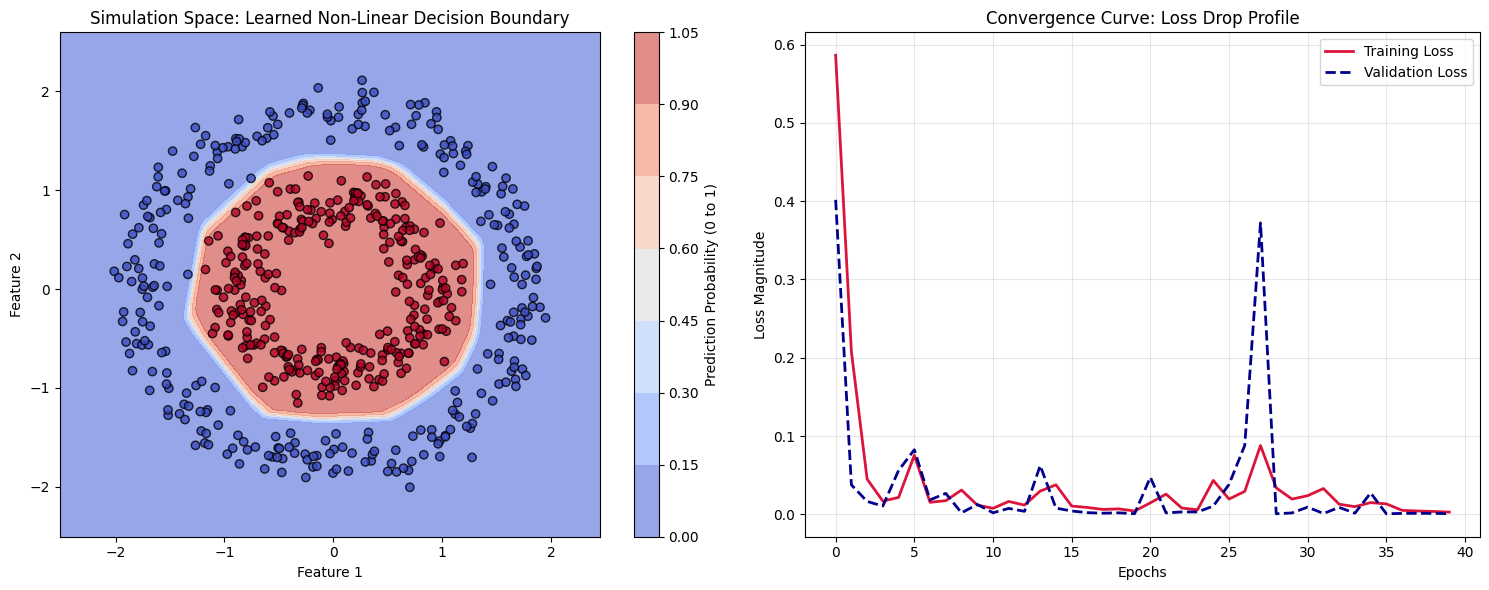

In [8]:
# Topic 151 | ANN - Neural Network Simulation
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

print("=== STARTING NEURAL NETWORK SIMULATION ENGINE ===")

# 1. Dataset Generation: Concentric Circles (Aik circle ke andar dusra circle)
# Yeh data linear algorithms (like logistic regression) se kabhi solve nahi ho sakta
X_raw, y = make_circles(n_samples=600, noise=0.08, factor=0.5, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Designing a Deep Network for Complex Geometry
model = Sequential([
    Input(shape=(2,)),                                # 2D Space Inputs (X, Y coordinates)
    Dense(units=32, activation='relu', name='Hidden_1'), # Higher neurons to capture curvature
    Dense(units=16, activation='relu', name='Hidden_2'),
    Dense(units=1, activation='sigmoid', name='Output')  # Probability output
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.03),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Running the Simulation Loop & Saving History
print("\nSimulating Neural Network Training over 40 Epochs...")
history = model.fit(
    X_scaled, y, 
    epochs=40, 
    batch_size=32, 
    validation_split=0.2,
    verbose=0  # Progress logs ko clean rakhne ke liye verbose 0 kiya hai
)

print("Simulation Complete! Preparing Visual Dashboard...")

# ------------------------------------------------------------------
# 4. DECISION BOUNDARY MESH GENERATION (The Simulation Visualizer)
# ------------------------------------------------------------------
# Grid points create karte hain pure data space ko cover karne ke liye
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Matrix space par predictions run karte hain
grid_predictions = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
grid_predictions = grid_predictions.reshape(xx.shape)

# Plotting the Simulation Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Dashboard Pane 1: Learned Decision Boundary Space
contour = ax1.contourf(xx, yy, grid_predictions, cmap='coolwarm', alpha=0.6)
scatter = ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
ax1.set_title('Simulation Space: Learned Non-Linear Decision Boundary', fontsize=12)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
fig.colorbar(contour, ax=ax1, label='Prediction Probability (0 to 1)')

# Dashboard Pane 2: Convergence Metrics (Loss Convergence)
ax2.plot(history.history['loss'], label='Training Loss', color='crimson', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='darkblue', linewidth=2, linestyle='--')
ax2.set_title('Convergence Curve: Loss Drop Profile', fontsize=12)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Magnitude')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()